In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales = pd.read_csv("D:/foresight-demand-inventory-intelligence/Raw Datsets/sales_daily.csv")

sku_master = pd.read_csv("D:/foresight-demand-inventory-intelligence/Raw Datsets/sku_master.csv")

calendar = pd.read_csv("D:/foresight-demand-inventory-intelligence/Raw Datsets/calendar.csv")

inventory = pd.read_csv("D:/foresight-demand-inventory-intelligence/Raw Datsets/inventory_snapshots.csv")

In [3]:
print("Sales data:", sales.shape)
print("SKU master:", sku_master.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Sales data: (36550, 6)
SKU master: (50, 8)
Calendar: (731, 11)
Inventory: (4800, 8)


In [4]:
sales.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [5]:
sku_master.head()

,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,SKU003,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,SKU004,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,SKU005,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59


In [6]:
calendar.head()

,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


In [7]:
inventory.head()

,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89


In [8]:
print("Sales columns:")
print(sales.columns.tolist())

print("/nSKU Master columns:")
print(sku_master.columns.tolist())

print("/nCalendar columns:")
print(calendar.columns.tolist())

print("/nInventory columns:")
print(inventory.columns.tolist())

Sales columns:
['Date', 'SKU', 'Units_Sold', 'Revenue', 'Price', 'Promotion']
/nSKU Master columns:
['SKU', 'Product_Name', 'Category', 'Subcategory', 'Launch_Date', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit']
/nCalendar columns:
['date', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'season', 'holiday', 'is_holiday', 'promotion_event']
/nInventory columns:
['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value']


In [9]:
# Understand the data types
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 36550 entries, 0 to 36549
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        36550 non-null  str    
 1   SKU         36550 non-null  str    
 2   Units_Sold  36550 non-null  int64  
 3   Revenue     36550 non-null  float64
 4   Price       36550 non-null  float64
 5   Promotion   36550 non-null  int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 1.7 MB


In [10]:
sku_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SKU                    50 non-null     str    
 1   Product_Name           50 non-null     str    
 2   Category               50 non-null     str    
 3   Subcategory            50 non-null     str    
 4   Launch_Date            50 non-null     str    
 5   Cost_Price             50 non-null     float64
 6   Selling_Price          50 non-null     float64
 7   Gross_Margin_Per_Unit  50 non-null     float64
dtypes: float64(3), str(5)
memory usage: 3.3 KB


In [11]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             731 non-null    str  
 1   year             731 non-null    int64
 2   month            731 non-null    int64
 3   quarter          731 non-null    str  
 4   week             731 non-null    int64
 5   day_of_week      731 non-null    str  
 6   is_weekend       731 non-null    int64
 7   season           731 non-null    str  
 8   holiday          8 non-null      str  
 9   is_holiday       731 non-null    int64
 10  promotion_event  75 non-null     str  
dtypes: int64(5), str(6)
memory usage: 62.9 KB


In [12]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Snapshot_Date    4800 non-null   str    
 1   SKU              4800 non-null   str    
 2   Current_Stock    4800 non-null   int64  
 3   On_Order         4800 non-null   int64  
 4   Lead_Time_Days   4800 non-null   int64  
 5   Safety_Stock     4800 non-null   int64  
 6   Reorder_Point    4800 non-null   int64  
 7   Inventory_Value  4800 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 300.1 KB


In [13]:
# check missing values in each dataset

sales.isnull().sum()

Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

In [14]:
sku_master.isnull().sum()

SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

In [15]:
calendar.isnull().sum()

date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64

In [16]:
inventory.isnull().sum()

Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

In [17]:
# Check duplicates

print("Sales duplicates:", sales.duplicated().sum())
print("SKU Master duplicates:", sku_master.duplicated().sum())
print("Calendar duplicates:", calendar.duplicated().sum())
print("Inventory duplicates:", inventory.duplicated().sum())

Sales duplicates: 0
SKU Master duplicates: 0
Calendar duplicates: 0
Inventory duplicates: 0


In [18]:
# basic statistics

sales.describe()

,Units_Sold,Revenue,Price,Promotion
count,36550.000000,36550.00000,36550.000000,36550.000000
mean,14.003010,84707.43385,5892.663800,0.102599
std,8.467305,76534.63044,3138.775609,0.303439
min,0.000000,0.00000,663.460000,0.000000
25%,7.000000,27643.70000,3484.090000,0.000000
50%,13.000000,56125.90000,5649.795000,0.000000
75%,20.000000,127954.32000,8516.600000,0.000000
max,56.000000,546977.00000,11642.450000,1.000000


In [19]:
sku_master.describe()

,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
count,50.000000,50.000000,50.000000
mean,3770.729400,5892.663800,2121.934400
std,2025.786477,3170.598793,3784.884812
min,307.060000,663.460000,-5484.320000
25%,1936.910000,3502.567500,-579.570000
50%,3836.845000,5649.795000,1790.025000
75%,5514.770000,8506.780000,4846.322500
max,7748.200000,11642.450000,10224.930000


In [20]:
inventory.describe()

,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4.800000e+03
mean,304.143333,213.093750,8.438958,83.152708,211.745417,1.304166e+06
std,280.890448,244.456955,3.488024,70.256045,179.905422,1.741551e+06
min,2.000000,0.000000,3.000000,5.000000,10.000000,2.444200e+03
25%,109.000000,49.000000,5.000000,35.000000,87.000000,2.521855e+05
50%,229.000000,135.000000,8.000000,67.000000,169.000000,6.837389e+05
75%,418.000000,292.000000,11.250000,112.000000,286.000000,1.720023e+06
max,2585.000000,3060.000000,14.000000,746.000000,1661.000000,2.027987e+07


In [21]:
calendar.describe()

,year,month,week,is_weekend,is_holiday
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2024.499316,6.519836,26.395349,0.284542,0.010944
std,0.500342,3.451913,15.076278,0.451505,0.104110
min,2024.000000,1.000000,1.000000,0.000000,0.000000
25%,2024.000000,4.000000,13.000000,0.000000,0.000000
50%,2024.000000,7.000000,26.000000,0.000000,0.000000
75%,2025.000000,10.000000,39.000000,1.000000,0.000000
max,2025.000000,12.000000,52.000000,1.000000,1.000000


In [22]:
# unique SKU Level

sales["SKU"].nunique()
sku_master["SKU"].nunique()
inventory["SKU"].nunique()

200

In [23]:
sales.columns.tolist()
sku_master.columns.tolist()
calendar.columns.tolist()
inventory.columns.tolist()

['Snapshot_Date',
 'SKU',
 'Current_Stock',
 'On_Order',
 'Lead_Time_Days',
 'Safety_Stock',
 'Reorder_Point',
 'Inventory_Value']

In [24]:
sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)

sales["Date"].isna().sum()

np.int64(0)

In [25]:
calendar["date"] = pd.to_datetime(
    calendar["date"],
    errors="coerce"
)

calendar["date"].isna().sum()

np.int64(0)

In [26]:
# date ranges

print("Sales date range:")
print("Start:", sales["Date"].min())
print("End:", sales["Date"].max())

print("Calendar date range:")
print("Start:", calendar["date"].min())
print("End:", calendar["date"].max())

print("Inventory date range:")
print("Start:", inventory["Snapshot_Date"].min())
print("End:", inventory["Snapshot_Date"].max())

Sales date range:
Start: 2024-01-01 00:00:00
End: 2025-12-31 00:00:00
Calendar date range:
Start: 2024-01-01 00:00:00
End: 2025-12-31 00:00:00
Inventory date range:
Start: 2024-01-01
End: 2025-12-01


In [27]:
# Check SKU consistency

sales_skus = set(
    sales["SKU"].dropna().unique()
)

master_skus = set(
    sku_master["SKU"].dropna().unique()
)

sales_not_in_master = sales_skus - master_skus

print("Number of sales SKUs missing from SKU master:",
      len(sales_not_in_master))

print(sales_not_in_master)


Number of sales SKUs missing from SKU master: 0
set()


In [28]:
# duplicate SKU records in SKU Master

sku_master_duplicates = sku_master[sku_master.duplicated(subset=["SKU"], keep=False)]

sku_master[
    sku_master["SKU"].duplicated(keep=False)
].sort_values("SKU")


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit


In [29]:
# duplicate calendar dates
calendar["date"].duplicated().sum()
calendar_duplicates = calendar[calendar.duplicated(subset=["date"], keep=False)]

In [30]:
# sales SKU/date combinations

sales.duplicated(
    subset=["SKU", "Date"]
).sum()

sales[
    sales.duplicated(
        subset=["SKU", "Date"],
        keep=False
    )
].sort_values(["SKU", "Date"])


,Date,SKU,Units_Sold,Revenue,Price,Promotion


In [31]:
# inventory SKU/date combinations

inventory.duplicated(
    subset=["SKU", "Snapshot_Date"]
).sum()

np.int64(0)

In [32]:
# validating summary statistics for inventory dataset

validation_summary = pd.DataFrame({
    "check": [
        "Sales invalid dates",
        "Calendar invalid dates",
        "Inventory invalid dates",
        "Negative units sold",
        "Negative revenue",
        "Negative price",
        "Duplicate SKU master IDs",
        "Duplicate calendar dates",
        "Duplicate sales SKU-date combinations",
        "Duplicate inventory SKU-date combinations"
    ],
    "count": [
        sales["Date"].isna().sum(),
        calendar["date"].isna().sum(),
        inventory["Snapshot_Date"].isna().sum(),
        (sales["Units_Sold"] < 0).sum(),
        (sales["Revenue"] < 0).sum(),
        (sales["Price"] < 0).sum(),
        sku_master["SKU"].duplicated().sum(),
        calendar["date"].duplicated().sum(),
        sales.duplicated(subset=["SKU", "Date"]).sum(),
        inventory.duplicated(subset=["SKU", "Snapshot_Date"]).sum()
    ]
})

validation_summary

,check,count
0,Sales invalid dates,0
1,Calendar invalid dates,0
2,Inventory invalid dates,0
3,Negative units sold,0
4,Negative revenue,0
5,Negative price,0
6,Duplicate SKU master IDs,0
7,Duplicate calendar dates,0
8,Duplicate sales SKU-date combinations,0
9,Duplicate inventory SKU-date combinations,0


In [33]:
# STEP 3: IN THIS PART I WILL COMBINIING THE 4 DATASETS INTO ONE DATASET FOR FURTHER ANALYSIS. SALES, SKU MASTER, CALENDAR AND INVENTORY DATASETS WILL BE MERGED INTO ONE DATASET.

sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")
inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"], errors="coerce"
)
sku_master["Launch_Date"] = pd.to_datetime(
    sku_master["Launch_Date"], errors="coerce"
)

analysis_df = sales.copy()

analysis_df.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [34]:
# here i have merged the sales dataset with the sku_master dataset on the "SKU" column using a left join. This means that all records from the sales dataset will be retained, and matching records from the sku_master dataset will be added where available. If there are SKUs in the sales dataset that do not have corresponding entries in the sku_master dataset, those records will still be included in the analysis_df, but with NaN values for the columns from sku_master.
analysis_df = analysis_df.merge(
    sku_master,
    on="SKU",
    how="left"
)

analysis_df.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,2024-01-01,SKU001,5,18320.25,3664.05,0,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,2024-01-01,SKU002,15,57085.35,3805.69,0,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,2024-01-01,SKU003,5,40391.15,8078.23,0,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,2024-01-01,SKU004,5,34307.85,6861.57,0,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,2024-01-01,SKU005,12,113918.64,9493.22,0,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59


In [35]:
analysis_df.shape

(36550, 13)

In [36]:
analysis_df.columns.tolist()

['Date',
 'SKU',
 'Units_Sold',
 'Revenue',
 'Price',
 'Promotion',
 'Product_Name',
 'Category',
 'Subcategory',
 'Launch_Date',
 'Cost_Price',
 'Selling_Price',
 'Gross_Margin_Per_Unit']

In [37]:
# now iam merging calender dataset

analysis_df = analysis_df.merge(
    calendar,
    left_on="Date",
    right_on="date",
    how="left"
)
analysis_df.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion,Product_Name,Category,Subcategory,Launch_Date,...,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,SKU001,5,18320.25,3664.05,0,Product 001,Furniture,Chair,2022-04-09,...,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-01,SKU002,15,57085.35,3805.69,0,Product 002,Home Decor,Table,2024-05-01,...,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
2,2024-01-01,SKU003,5,40391.15,8078.23,0,Product 003,Kitchen,Cushion,2023-12-22,...,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
3,2024-01-01,SKU004,5,34307.85,6861.57,0,Product 004,Lighting,Cookware,2023-04-28,...,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
4,2024-01-01,SKU005,12,113918.64,9493.22,0,Product 005,Storage,Lamp,2023-04-22,...,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN


In [38]:
# now checking the shape of the final merged dataset
analysis_df.shape

(36550, 24)

In [39]:
analysis_df.columns.tolist()

['Date',
 'SKU',
 'Units_Sold',
 'Revenue',
 'Price',
 'Promotion',
 'Product_Name',
 'Category',
 'Subcategory',
 'Launch_Date',
 'Cost_Price',
 'Selling_Price',
 'Gross_Margin_Per_Unit',
 'date',
 'year',
 'month',
 'quarter',
 'week',
 'day_of_week',
 'is_weekend',
 'season',
 'holiday',
 'is_holiday',
 'promotion_event']

In [40]:
# now again iam adding the inventory dataset to the analysis_df using a left join on the "SKU" and "Date" columns. This will ensure that all records from the analysis_df are retained, and matching records from the inventory dataset will be added where available. If there are SKUs in the analysis_df that do not have corresponding entries in the inventory dataset, those records will still be included in the final merged dataset, but with NaN values for the columns from inventory.
analysis_df = analysis_df.merge(
    inventory,
    left_on=["SKU", "Date"],
    right_on=["SKU", "Snapshot_Date"],
    how="left"
)
analysis_df.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion,Product_Name,Category,Subcategory,Launch_Date,...,holiday,is_holiday,promotion_event,Snapshot_Date,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,5,18320.25,3664.05,0,Product 001,Furniture,Chair,2022-04-09,...,NaN,0,NaN,2024-01-01,16.0,23.0,11.0,7.0,18.0,58420.96
1,2024-01-01,SKU002,15,57085.35,3805.69,0,Product 002,Home Decor,Table,2024-05-01,...,NaN,0,NaN,2024-01-01,29.0,12.0,4.0,5.0,10.0,163983.40
2,2024-01-01,SKU003,5,40391.15,8078.23,0,Product 003,Kitchen,Cushion,2023-12-22,...,NaN,0,NaN,2024-01-01,34.0,23.0,14.0,6.0,20.0,209060.22
3,2024-01-01,SKU004,5,34307.85,6861.57,0,Product 004,Lighting,Cookware,2023-04-28,...,NaN,0,NaN,2024-01-01,34.0,4.0,7.0,5.0,12.0,42257.92
4,2024-01-01,SKU005,12,113918.64,9493.22,0,Product 005,Storage,Lamp,2023-04-22,...,NaN,0,NaN,2024-01-01,23.0,5.0,5.0,6.0,11.0,170945.89


In [41]:
analysis_df.shape

(36550, 31)

In [42]:
analysis_df.columns.tolist()

['Date',
 'SKU',
 'Units_Sold',
 'Revenue',
 'Price',
 'Promotion',
 'Product_Name',
 'Category',
 'Subcategory',
 'Launch_Date',
 'Cost_Price',
 'Selling_Price',
 'Gross_Margin_Per_Unit',
 'date',
 'year',
 'month',
 'quarter',
 'week',
 'day_of_week',
 'is_weekend',
 'season',
 'holiday',
 'is_holiday',
 'promotion_event',
 'Snapshot_Date',
 'Current_Stock',
 'On_Order',
 'Lead_Time_Days',
 'Safety_Stock',
 'Reorder_Point',
 'Inventory_Value']

In [43]:
# check_missing_values

analysis_df.isnull().sum()

Date                         0
SKU                          0
Units_Sold                   0
Revenue                      0
Price                        0
Promotion                    0
Product_Name                 0
Category                     0
Subcategory                  0
Launch_Date                  0
Cost_Price                   0
Selling_Price                0
Gross_Margin_Per_Unit        0
date                         0
year                         0
month                        0
quarter                      0
week                         0
day_of_week                  0
is_weekend                   0
season                       0
holiday                  36150
is_holiday                   0
promotion_event          32800
Snapshot_Date            35350
Current_Stock            35350
On_Order                 35350
Lead_Time_Days           35350
Safety_Stock             35350
Reorder_Point            35350
Inventory_Value          35350
dtype: int64

In [44]:
# checking duplicates again avter merging all table datasets
analysis_df.duplicated().sum()

np.int64(0)

In [45]:
print("Sales rows:", len(sales))
print("Final analysis rows:", len(analysis_df))

Sales rows: 36550
Final analysis rows: 36550


In [46]:
analysis_df.shape
analysis_df.duplicated().sum()
analysis_df.isnull().sum()

Date                         0
SKU                          0
Units_Sold                   0
Revenue                      0
Price                        0
Promotion                    0
Product_Name                 0
Category                     0
Subcategory                  0
Launch_Date                  0
Cost_Price                   0
Selling_Price                0
Gross_Margin_Per_Unit        0
date                         0
year                         0
month                        0
quarter                      0
week                         0
day_of_week                  0
is_weekend                   0
season                       0
holiday                  36150
is_holiday                   0
promotion_event          32800
Snapshot_Date            35350
Current_Stock            35350
On_Order                 35350
Lead_Time_Days           35350
Safety_Stock             35350
Reorder_Point            35350
Inventory_Value          35350
dtype: int64

In [47]:
# saving dataset after combining all datasets

analysis_df.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/analysis_ready.csv",
    index=False
)

In [48]:
# STAGE 4: EDA (EXPLORATORY DATA ANALYSIS)
# 1. Overall sales performance
# 2. Top performing SKUs
# 3. Sales performance by Category 
# 4. sales over time
# 5. promotions and non promotional analysis
# 6. seasonality and trend analysis
# 7. Inventory position analysis

# This section will focus on performing exploratory data analysis (EDA) on the combined dataset to gain insights into sales performance, top-performing SKUs, sales trends over time, and inventory position. The analysis will help identify patterns, trends, and potential areas for improvement in inventory management and sales strategies.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/foresight-demand-inventory-intelligence/processed/analysis_ready.csv")

analysis_df["Date"] = pd.to_datetime(analysis_df["Date"], errors="coerce")

if "date" in analysis_df.columns:
    analysis_df["date"] = pd.to_datetime(analysis_df["date"], errors="coerce")

if "snapshot_Date" in analysis_df.columns:
    analysis_df["snapshot_Date"] = pd.to_datetime(analysis_df["snapshot_Date"], errors="coerce")

print("Dataset shape:", analysis_df.shape)
print("/nColumns:")
print("Columns:", analysis_df.columns.tolist())

print("/nFirst 5 rows:")
print(analysis_df.head())

print("/nData types:")
print(analysis_df.dtypes)

Dataset shape: (36550, 31)
/nColumns:
Columns: ['Date', 'SKU', 'Units_Sold', 'Revenue', 'Price', 'Promotion', 'Product_Name', 'Category', 'Subcategory', 'Launch_Date', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit', 'date', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'season', 'holiday', 'is_holiday', 'promotion_event', 'Snapshot_Date', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value']
/nFirst 5 rows:
        Date     SKU  Units_Sold    Revenue    Price  Promotion Product_Name  \
0 2024-01-01  SKU001           5   18320.25  3664.05          0  Product 001   
1 2024-01-01  SKU002          15   57085.35  3805.69          0  Product 002   
2 2024-01-01  SKU003           5   40391.15  8078.23          0  Product 003   
3 2024-01-01  SKU004           5   34307.85  6861.57          0  Product 004   
4 2024-01-01  SKU005          12  113918.64  9493.22          0  Product 005   

     Category Subcategory Launch_Dat

In [49]:
# 2. Overall Sales Performance
# Overall sales summary

print("Total Units Sold:", analysis_df["Units_Sold"].sum())
print("Total Revenue:", analysis_df["Revenue"].sum())
print("Average Units Sold per Record:", analysis_df["Units_Sold"].mean())
print("Average Revenue per Record:", analysis_df["Revenue"].mean())
print("Number of SKUs:", analysis_df["SKU"].nunique())
print("Number of Sales Records:", len(analysis_df))

print("/nSales Date Range:")
print("Start:", analysis_df["Date"].min())
print("End:", analysis_df["Date"].max())

print("/nSales Summary Statistics:")
display(
    analysis_df[["Units_Sold", "Revenue", "Price"]].describe()
)

Total Units Sold: 511810
Total Revenue: 3096056707.22
Average Units Sold per Record: 14.003009575923393
Average Revenue per Record: 84707.4338500684
Number of SKUs: 50
Number of Sales Records: 36550
/nSales Date Range:
Start: 2024-01-01 00:00:00
End: 2025-12-31 00:00:00
/nSales Summary Statistics:


,Units_Sold,Revenue,Price
count,36550.000000,36550.00000,36550.000000
mean,14.003010,84707.43385,5892.663800
std,8.467305,76534.63044,3138.775609
min,0.000000,0.00000,663.460000
25%,7.000000,27643.70000,3484.090000
50%,13.000000,56125.90000,5649.795000
75%,20.000000,127954.32000,8516.600000
max,56.000000,546977.00000,11642.450000


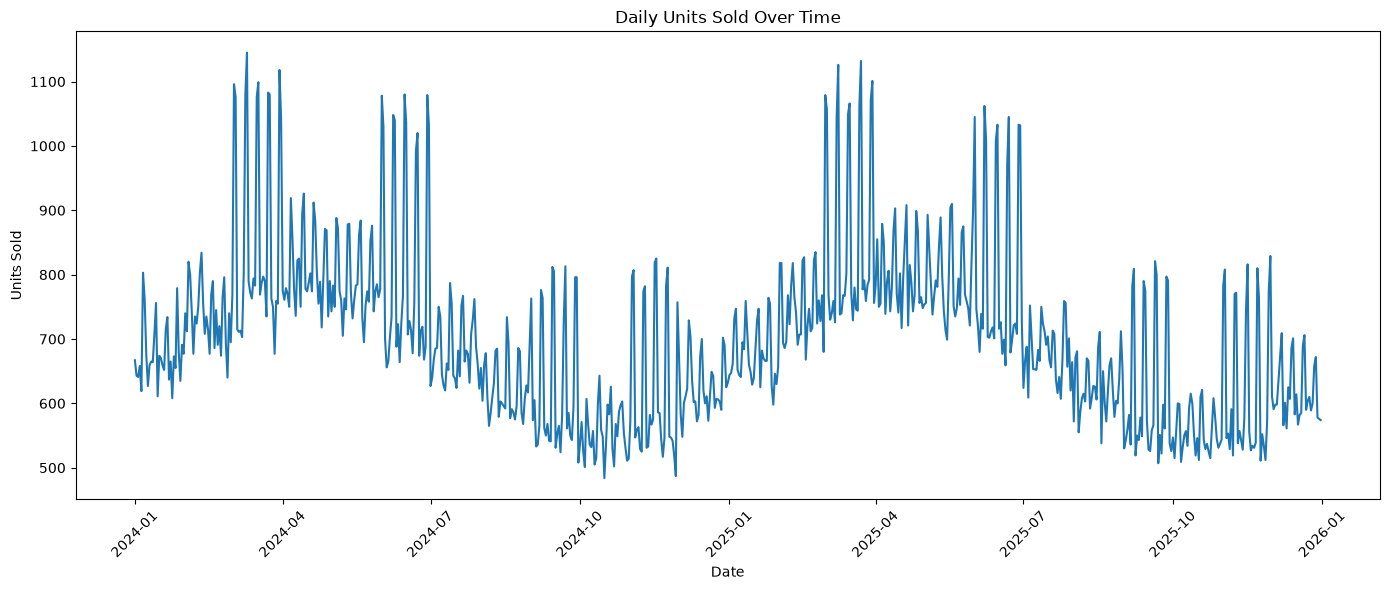

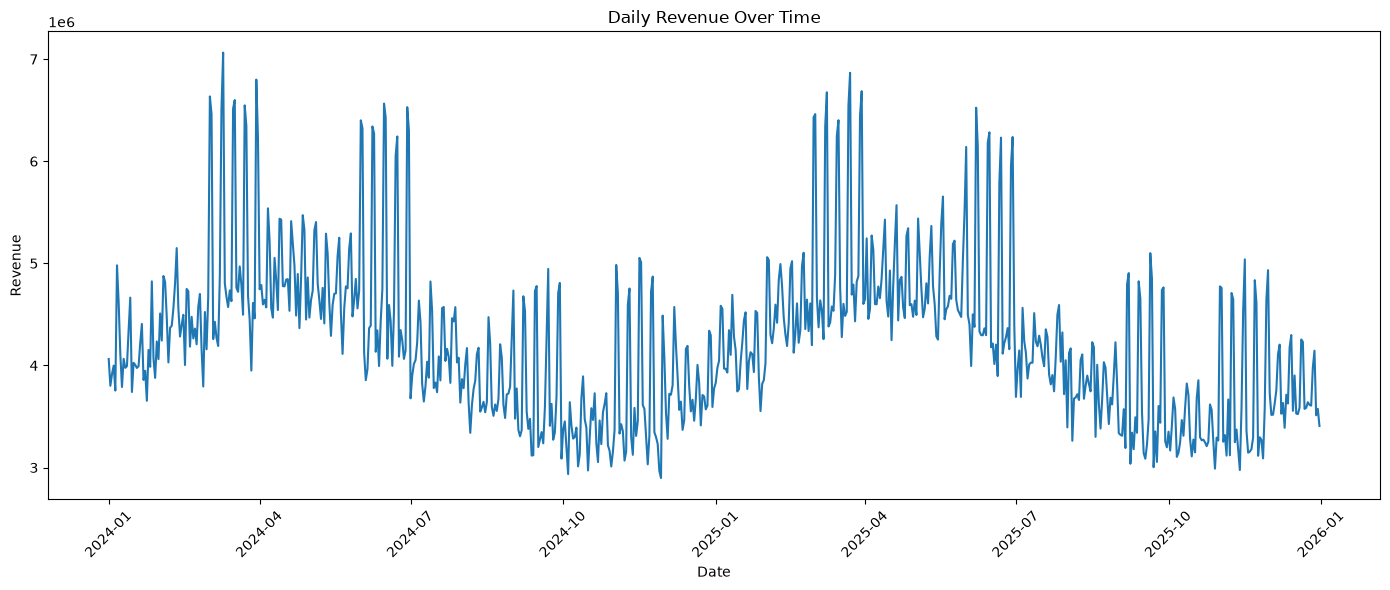

In [50]:
# 3. Top Performing SKUs
# Aggregate daily sales

daily_sales = (
    analysis_df
    .groupby("Date", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum")
    )
)

# Plot daily units sold

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_sales,
    x="Date",
    y="Units_Sold"
)

plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plot daily revenue

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_sales,
    x="Date",
    y="Revenue"
)

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Category,Units_Sold,Revenue,Number_of_SKUs
1,Home Decor,132570,8.884681e+08,10
0,Furniture,82298,6.033905e+08,10
4,Storage,93367,5.819274e+08,10
2,Kitchen,101144,5.635346e+08,10
3,Lighting,102431,4.587362e+08,10


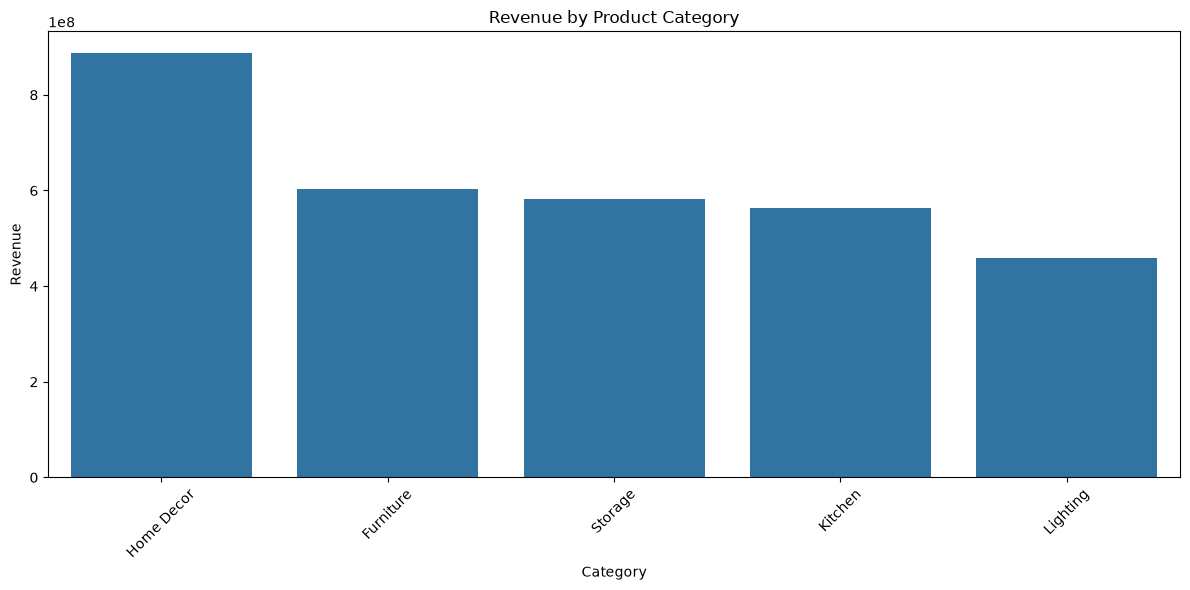

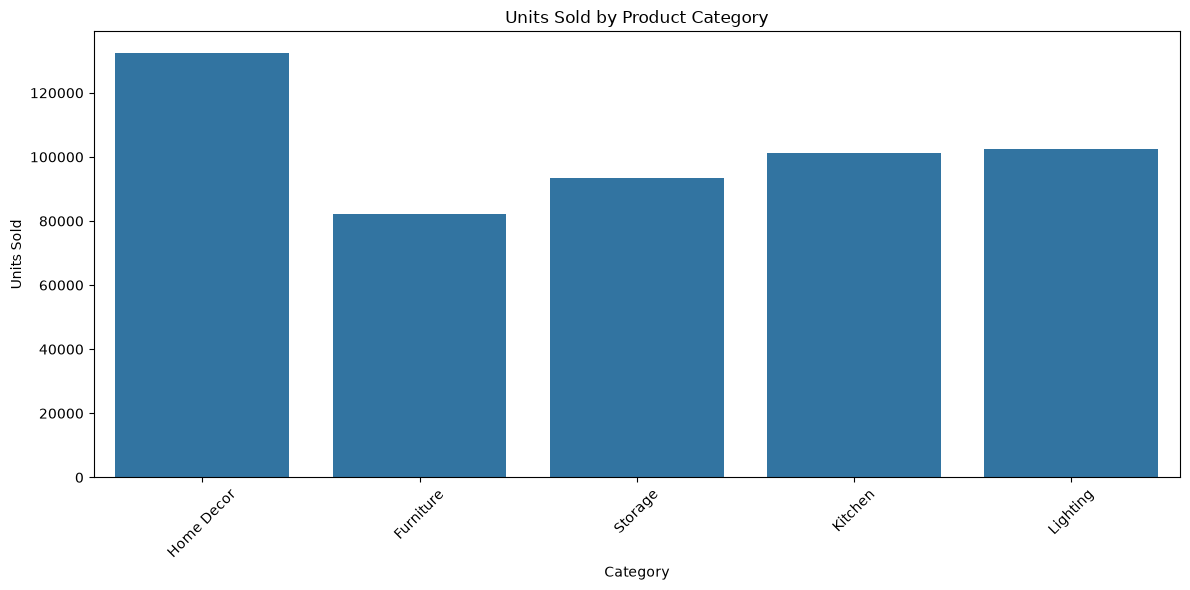

In [51]:
# 4. Sales Performance by Category

category_sales = (
    analysis_df
    .groupby("Category", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Number_of_SKUs=("SKU", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

display(category_sales)


# Revenue by category

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Revenue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Units sold by category

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Units_Sold"
)

plt.title("Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Promotion,Total_Units_Sold,Total_Revenue,Average_Units_Sold,Average_Revenue,Number_of_Records
0,0,442011,2.674843e+09,13.475945,81550.078302,32800
1,1,69799,4.212141e+08,18.613067,112323.770379,3750


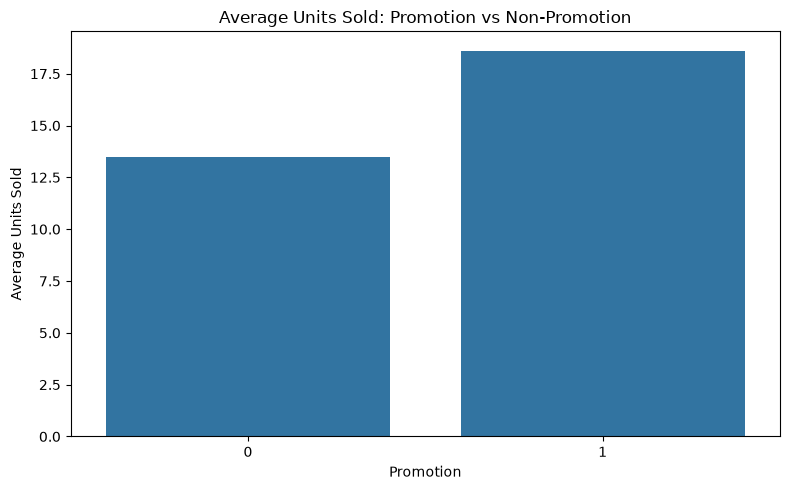

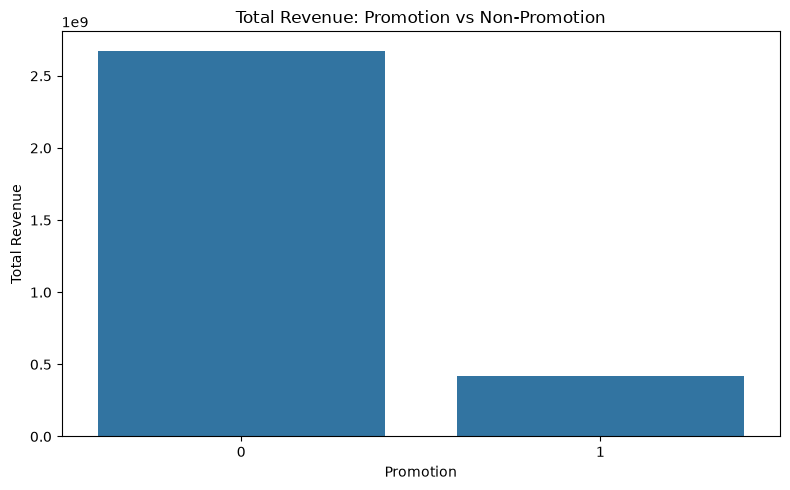

In [52]:
# 5. Promotions and Non-Promotional Analysis

promotion_summary = (
    analysis_df
    .groupby("Promotion", as_index=False)
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Average_Units_Sold=("Units_Sold", "mean"),
        Average_Revenue=("Revenue", "mean"),
        Number_of_Records=("SKU", "count")
    )
)

display(promotion_summary)


# Average units sold during promotion vs non-promotion

plt.figure(figsize=(8, 5))

sns.barplot(
    data=promotion_summary,
    x="Promotion",
    y="Average_Units_Sold"
)

plt.title("Average Units Sold: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()


# Total revenue during promotion vs non-promotion

plt.figure(figsize=(8, 5))

sns.barplot(
    data=promotion_summary,
    x="Promotion",
    y="Total_Revenue"
)

plt.title("Total Revenue: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

,season,Units_Sold,Revenue,Average_Units_Sold
4,Winter,122704,7.442873e+08,13.558453
1,Monsoon,118001,7.140896e+08,12.826196
2,Spring,101684,6.141112e+08,16.669508
3,Summer,97654,5.900151e+08,16.008852
0,Autumn,71767,4.335536e+08,11.765082


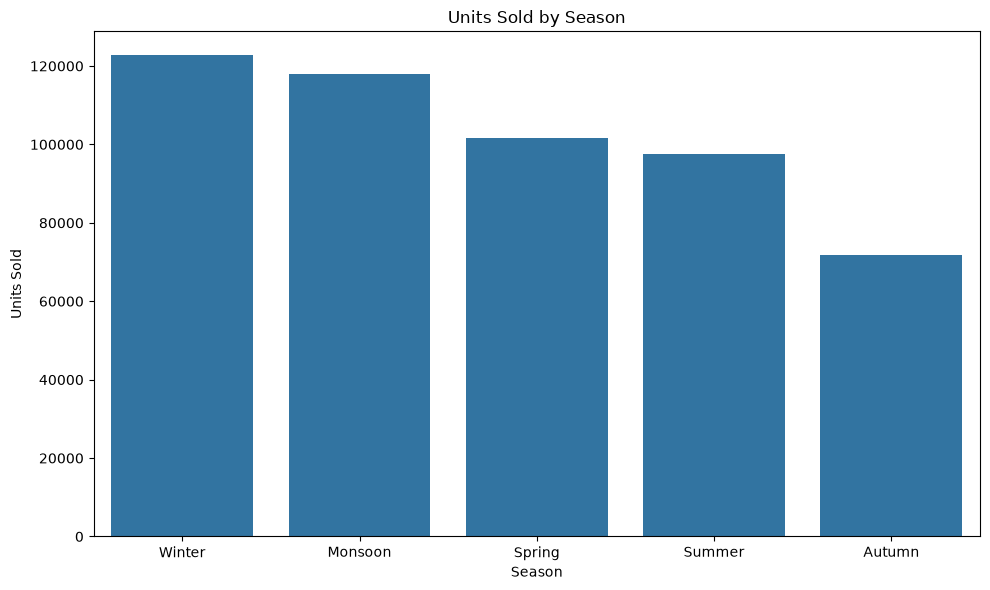

,day_of_week,Average_Units_Sold,Total_Units_Sold
0,Friday,13.185962,68567
1,Monday,13.034286,68430
2,Saturday,16.279231,84652
3,Sunday,16.379808,85175
4,Thursday,13.114038,68193
5,Tuesday,13.017524,68342
6,Wednesday,13.038286,68451


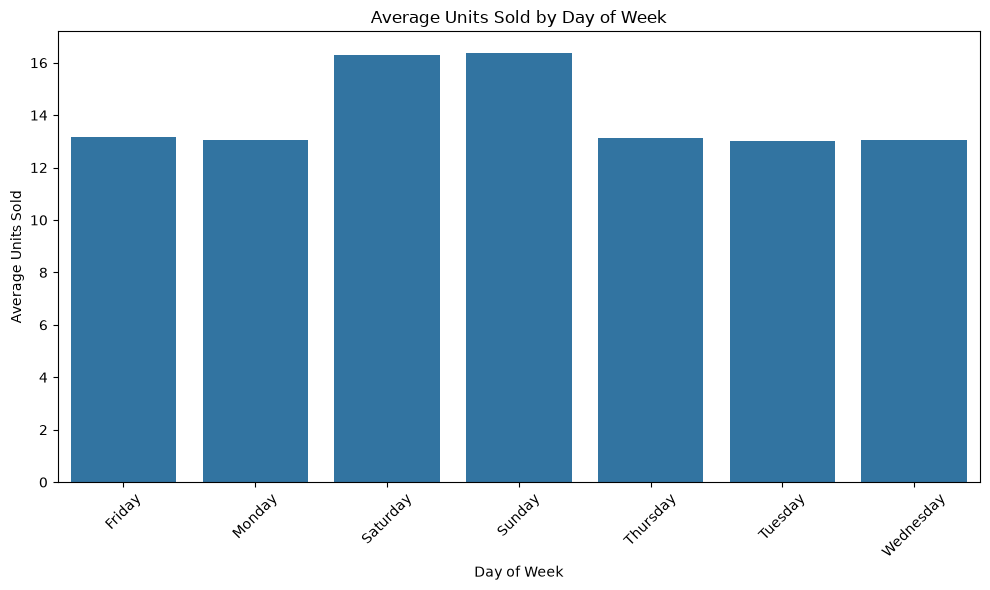

Weekend vs Weekday:


,is_weekend,Average_Units_Sold,Total_Units_Sold,Average_Revenue,Total_Revenue
0,0,13.077744,341983,79131.873292,2.069298e+09
1,1,16.329519,169827,98726.751985,1.026758e+09


Holiday vs Non-Holiday:


,is_holiday,Average_Units_Sold,Total_Units_Sold,Average_Revenue,Total_Revenue
0,0,14.023402,506946,84827.148482,3.066501e+09
1,1,12.160000,4864,73888.224025,2.955529e+07


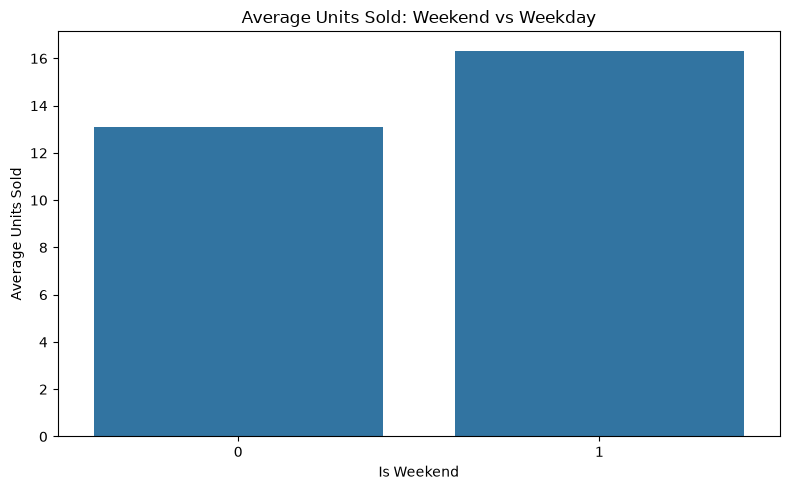

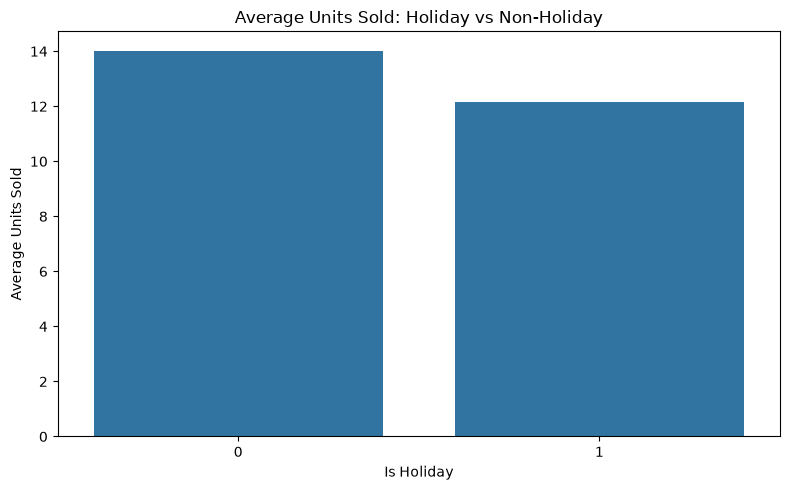

In [53]:
# 6. Seasonality and Trend Analysis
season_sales = (
    analysis_df
    .groupby("season", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Average_Units_Sold=("Units_Sold", "mean")
    )
    .sort_values("Units_Sold", ascending=False)
)

display(season_sales)


# Units sold by season

plt.figure(figsize=(10, 6))

sns.barplot(
    data=season_sales,
    x="season",
    y="Units_Sold"
)

plt.title("Units Sold by Season")
plt.xlabel("Season")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


# Average units sold by day of week

weekday_sales = (
    analysis_df
    .groupby("day_of_week", as_index=False)
    .agg(
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Units_Sold=("Units_Sold", "sum")
    )
)

display(weekday_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_sales,
    x="day_of_week",
    y="Average_Units_Sold"
)

plt.title("Average Units Sold by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Weekend and holiday analysis

weekend_summary = (
    analysis_df
    .groupby("is_weekend", as_index=False)
    .agg(
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Total_Revenue=("Revenue", "sum")
    )
)

print("Weekend vs Weekday:")
display(weekend_summary)


holiday_summary = (
    analysis_df
    .groupby("is_holiday", as_index=False)
    .agg(
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Total_Revenue=("Revenue", "sum")
    )
)

print("Holiday vs Non-Holiday:")
display(holiday_summary)


# Weekend comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekend_summary,
    x="is_weekend",
    y="Average_Units_Sold"
)

plt.title("Average Units Sold: Weekend vs Weekday")
plt.xlabel("Is Weekend")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()


# Holiday comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=holiday_summary,
    x="is_holiday",
    y="Average_Units_Sold"
)

plt.title("Average Units Sold: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()

Available inventory columns:
['Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value']


,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03
mean,308.706667,212.736667,8.494167,85.278333,217.670833,1.289199e+06
std,242.261538,206.450673,3.528268,63.005057,157.867167,1.326472e+06
min,5.000000,0.000000,3.000000,5.000000,10.000000,2.444200e+03
25%,127.000000,61.000000,5.000000,41.000000,101.000000,3.239485e+05
50%,249.500000,153.500000,9.000000,71.000000,183.000000,8.231890e+05
75%,435.000000,303.000000,12.000000,114.250000,301.000000,1.851320e+06
max,1844.000000,1706.000000,14.000000,413.000000,1041.000000,1.041211e+07


Inventory indicators created.
Records below safety stock: 25
Records below reorder point: 331


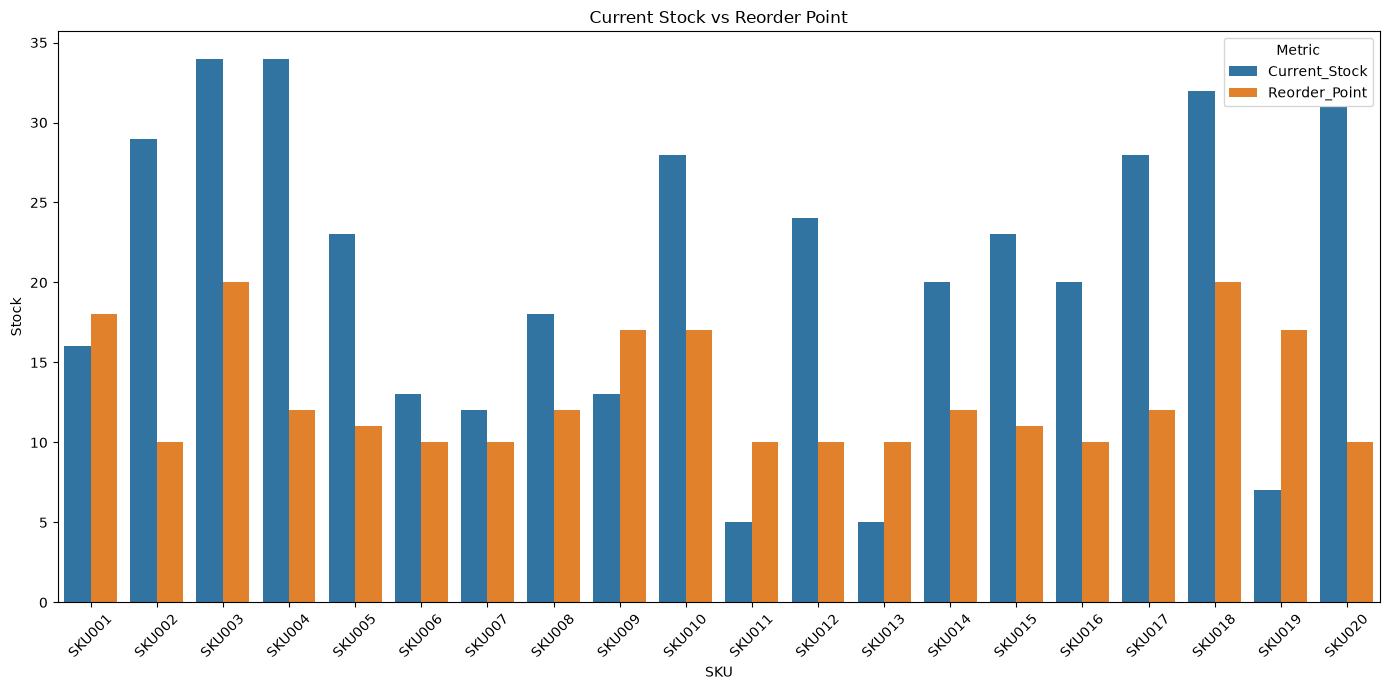

In [54]:
# 7. Inventory Position Analysis

inventory_columns = [
    "Current_Stock",
    "On_Order",
    "Lead_Time_Days",
    "Safety_Stock",
    "Reorder_Point",
    "Inventory_Value"
]

# Check which inventory columns are available
available_inventory_columns = [
    col for col in inventory_columns
    if col in analysis_df.columns
]

print("Available inventory columns:")
print(available_inventory_columns)

# Inventory summary
if available_inventory_columns:
    display(
        analysis_df[available_inventory_columns].describe()
    )


# Create inventory indicators

if "Current_Stock" in analysis_df.columns:
    analysis_df["Stock_Gap_to_Reorder"] = (
        analysis_df["Current_Stock"]
        - analysis_df["Reorder_Point"]
    )

if "Current_Stock" in analysis_df.columns and "Safety_Stock" in analysis_df.columns:
    analysis_df["Below_Safety_Stock"] = (
        analysis_df["Current_Stock"]
        < analysis_df["Safety_Stock"]
    )

if "Current_Stock" in analysis_df.columns and "Reorder_Point" in analysis_df.columns:
    analysis_df["Below_Reorder_Point"] = (
        analysis_df["Current_Stock"]
        < analysis_df["Reorder_Point"]
    )

print("Inventory indicators created.")

if "Below_Safety_Stock" in analysis_df.columns:
    print(
        "Records below safety stock:",
        analysis_df["Below_Safety_Stock"].sum()
    )

if "Below_Reorder_Point" in analysis_df.columns:
    print(
        "Records below reorder point:",
        analysis_df["Below_Reorder_Point"].sum()
    )

    # Inventory vs reorder point

if "Current_Stock" in analysis_df.columns and "Reorder_Point" in analysis_df.columns:

    inventory_sample = (
        analysis_df[
            ["SKU", "Current_Stock", "Reorder_Point"]
        ]
        .drop_duplicates("SKU")
        .head(20)
    )

    inventory_plot = inventory_sample.melt(
        id_vars="SKU",
        value_vars=["Current_Stock", "Reorder_Point"],
        var_name="Metric",
        value_name="Stock"
    )

    plt.figure(figsize=(14, 7))

    sns.barplot(
        data=inventory_plot,
        x="SKU",
        y="Stock",
        hue="Metric"
    )

    plt.title("Current Stock vs Reorder Point")
    plt.xlabel("SKU")
    plt.ylabel("Stock")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [55]:
# STEP 5: Naive Baseline (forecasting task requires weekly SKU-level demand forecasts.)

weekly_sales = sales.copy()

# Make sure Date is datetime
weekly_sales["Date"] = pd.to_datetime(
    weekly_sales["Date"],
    errors="coerce"
)

# Create Monday-based week
weekly_sales["Week_Start"] = (
    weekly_sales["Date"]
    - pd.to_timedelta(
        weekly_sales["Date"].dt.weekday,
        unit="D"
    )
)

# Aggregate daily sales into weekly SKU demand
weekly_demand = (
    weekly_sales
    .groupby(
        ["SKU", "Week_Start"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum")
    )
)

# Sort the dataset
weekly_demand = weekly_demand.sort_values(
    ["SKU", "Week_Start"]
).reset_index(drop=True)

print("Weekly demand shape:", weekly_demand.shape)

display(weekly_demand.head(10))

Weekly demand shape: (5250, 4)


,SKU,Week_Start,Units_Sold,Revenue
0,SKU001,2024-01-01,106,388389.30
1,SKU001,2024-01-08,85,311444.25
2,SKU001,2024-01-15,117,428693.85
3,SKU001,2024-01-22,89,326100.45
4,SKU001,2024-01-29,119,436021.95
5,SKU001,2024-02-05,112,410373.60
6,SKU001,2024-02-12,104,381061.20
7,SKU001,2024-02-19,120,439686.00
8,SKU001,2024-02-26,103,377397.15
9,SKU001,2024-03-04,119,436021.95


In [56]:
#  weekly demand

print("Number of SKUs:", weekly_demand["SKU"].nunique())
print("Number of weeks:", weekly_demand["Week_Start"].nunique())

print(
    "First week:",
    weekly_demand["Week_Start"].min()
)

print(
    "Last week:",
    weekly_demand["Week_Start"].max()
)

print("\nMissing values:")
display(weekly_demand.isnull().sum())

Number of SKUs: 50
Number of weeks: 105
First week: 2024-01-01 00:00:00
Last week: 2025-12-29 00:00:00

Missing values:


SKU           0
Week_Start    0
Units_Sold    0
Revenue       0
dtype: int64

In [57]:
# test period

all_week_dates = sorted(
    weekly_demand["Week_Start"].unique()
)

test_weeks = all_week_dates[-8:]

test_start = test_weeks[0]
test_end = test_weeks[-1]

print("Test period:")
print("Start:", test_start)
print("End:", test_end)

print("\nNumber of test weeks:", len(test_weeks))

Test period:
Start: 2025-11-10 00:00:00
End: 2025-12-29 00:00:00

Number of test weeks: 8


In [58]:
# Create seasonal-naive forecast

weekly_demand["Seasonal_Naive_Forecast"] = (
    weekly_demand
    .groupby("SKU")["Units_Sold"]
    .shift(52)
)

display(
    weekly_demand[
        [
            "SKU",
            "Week_Start",
            "Units_Sold",
            "Seasonal_Naive_Forecast"
        ]
    ].head(60)
)

# Select test observations

baseline_test = weekly_demand[
    weekly_demand["Week_Start"].isin(test_weeks)
].copy()

# Remove rows where a 52-week historical value is unavailable
baseline_test = baseline_test.dropna(
    subset=["Seasonal_Naive_Forecast"]
)

print("Baseline test rows:", len(baseline_test))

display(
    baseline_test.head(20)
)

,SKU,Week_Start,Units_Sold,Seasonal_Naive_Forecast
0,SKU001,2024-01-01,106,NaN
1,SKU001,2024-01-08,85,NaN
2,SKU001,2024-01-15,117,NaN
3,SKU001,2024-01-22,89,NaN
4,SKU001,2024-01-29,119,NaN
5,SKU001,2024-02-05,112,NaN
6,SKU001,2024-02-12,104,NaN
7,SKU001,2024-02-19,120,NaN
8,SKU001,2024-02-26,103,NaN
9,SKU001,2024-03-04,119,NaN


Baseline test rows: 400


,SKU,Week_Start,Units_Sold,Revenue,Seasonal_Naive_Forecast
97,SKU001,2025-11-10,87,318772.35,80.0
98,SKU001,2025-11-17,84,307780.20,88.0
99,SKU001,2025-11-24,84,307780.20,68.0
100,SKU001,2025-12-01,88,322436.40,83.0
101,SKU001,2025-12-08,89,326100.45,94.0
102,SKU001,2025-12-15,91,333428.55,77.0
103,SKU001,2025-12-22,76,278467.80,105.0
104,SKU001,2025-12-29,37,135569.85,78.0
202,SKU002,2025-11-10,60,228341.40,67.0
203,SKU002,2025-11-17,64,243564.16,66.0


In [59]:
# Calculate WAPE

absolute_error = (
    baseline_test["Units_Sold"]
    - baseline_test["Seasonal_Naive_Forecast"]
).abs()

wape = (
    absolute_error.sum()
    / baseline_test["Units_Sold"].sum()
) * 100

print(f"Seasonal Naive WAPE: {wape:.2f}%")

Seasonal Naive WAPE: 20.69%


In [60]:
# Calculate WAPE by SKU

def calculate_wape(group):
    actual = group["Units_Sold"].sum()
    
    if actual == 0:
        return np.nan
    
    error = (
        group["Units_Sold"]
        - group["Seasonal_Naive_Forecast"]
    ).abs().sum()
    
    return (error / actual) * 100


sku_baseline_performance = (
    baseline_test
    .groupby("SKU")
    .apply(calculate_wape)
    .reset_index(name="WAPE")
)

sku_baseline_performance = (
    sku_baseline_performance
    .sort_values("WAPE")
)

display(sku_baseline_performance.head(10))

,SKU,WAPE
42,SKU043,14.940239
16,SKU017,15.395894
34,SKU035,15.641293
43,SKU044,15.763547
29,SKU030,15.837104
19,SKU020,15.926493
18,SKU019,16.052632
13,SKU014,16.753382
4,SKU005,16.925065
17,SKU018,17.322835


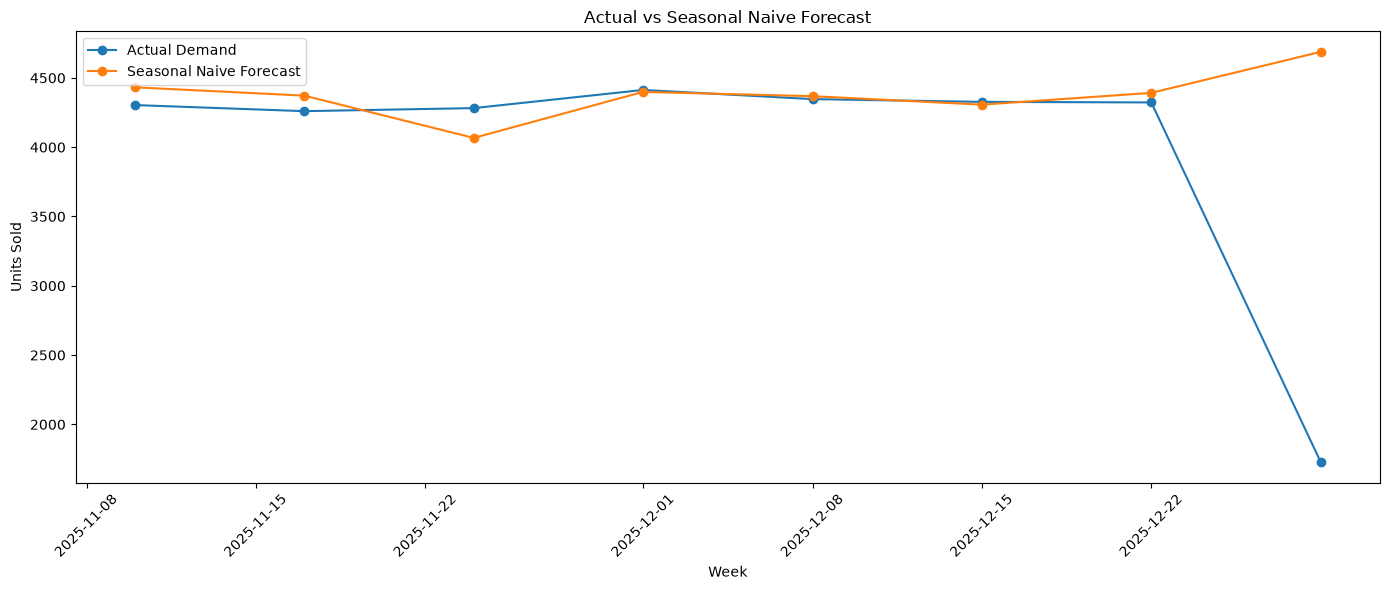

In [61]:
# Visualize actual vs baseline forecast

baseline_daily_view = (
    baseline_test
    .groupby("Week_Start", as_index=False)
    .agg(
        Actual_Demand=("Units_Sold", "sum"),
        Forecast_Demand=("Seasonal_Naive_Forecast", "sum")
    )
)

plt.figure(figsize=(14, 6))

plt.plot(
    baseline_daily_view["Week_Start"],
    baseline_daily_view["Actual_Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    baseline_daily_view["Week_Start"],
    baseline_daily_view["Forecast_Demand"],
    marker="o",
    label="Seasonal Naive Forecast"
)

plt.title("Actual vs Seasonal Naive Forecast")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# baseline results

weekly_demand.to_csv("D:/foresight-demand-inventory-intelligence/processed/weekly_demand_baseline.csv",
    index=False
)

sku_baseline_performance.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/sku_baseline_performance.csv",
    index=False
)

print("Baseline datasets saved successfully.")

Baseline datasets saved successfully.


In [63]:
import sys
print(sys.executable)

import sklearn
print("scikit-learn version:", sklearn.__version__)

d:\foresight-demand-inventory-intelligence\venv\Scripts\python.exe
scikit-learn version: 1.9.1


In [3]:
# Stage 6: Forecasting Model (model uses historical demand, rolling demand, calendar information, promotion, and price as predictive features)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    sklearn_available = True
except ImportError as error:
    sklearn_available = False
    print("scikit-learn is unavailable in this environment:")
    print(error)
    print("Continuing with pandas and NumPy only.")

weekly_model = pd.read_csv("D:/foresight-demand-inventory-intelligence/processed/weekly_demand_baseline.csv")

weekly_model["Week_Start"] = pd.to_datetime(
    weekly_model["Week_Start"], errors="coerce"
)

weekly_model = weekly_model.sort_values(
    ["SKU", "Week_Start"]
).reset_index(drop=True)

print("Weekly model dataset shape:", weekly_model.shape)

scikit-learn is unavailable in this environment:
DLL load failed while importing _liblinear: An Application Control policy has blocked this file.
Continuing with pandas and NumPy only.
Weekly model dataset shape: (5250, 5)


In [8]:
# calender features

weekly_model["Year"] = weekly_model["Week_Start"].dt.year
weekly_model["Month"] = weekly_model["Week_Start"].dt.month
weekly_model["Quarter"] = weekly_model["Week_Start"].dt.quarter
weekly_model["Week_Number"] = (
    weekly_model["Week_Start"].dt.isocalendar().week.astype(int)
)

weekly_model["Lag_1"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(1)
)

# Demand 2 weeks ago
weekly_model["Lag_2"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(2)
)

# Demand 4 weeks ago
weekly_model["Lag_4"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(4)
)

# Demand 8 weeks ago
weekly_model["Lag_8"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(8)
)

# Demand 12 weeks ago
weekly_model["Lag_12"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(12)
)

# Same period last year
weekly_model["Lag_52"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .shift(52)
)


In [11]:
# rolling-demand features
weekly_model["Rolling_Mean_4"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

weekly_model["Rolling_Mean_8"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(8).mean()
    )
)

weekly_model["Rolling_Mean_12"] = (
    weekly_model
    .groupby("SKU")["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(12).mean()
    )
)

# Load analysis-ready data
analysis_features = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/processed/analysis_ready.csv"
)

analysis_features["Date"] = pd.to_datetime(
    analysis_features["Date"],
    errors="coerce"
)

# Create the same week-start definition used above
analysis_features["Week_Start"] = (
    analysis_features["Date"]
    - pd.to_timedelta(
        analysis_features["Date"].dt.weekday,
        unit="D"
    )
)

# Aggregate weekly SKU-level explanatory variables
weekly_features = (
    analysis_features
    .groupby(["SKU", "Week_Start"], as_index=False)
    .agg(
        Average_Price=("Price", "mean"),
        Promotion=("Promotion", "max")
    )
)

# Merge these features into weekly model data
weekly_model = weekly_model.merge(
    weekly_features,
    on=["SKU", "Week_Start"],
    how="left"
)

In [18]:
# Model features
feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Lag_52",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",
    "Average_Price",
    "Promotion",
    "Year",
    "Month",
    "Quarter",
    "Week_Number",
]
target = "Units_Sold"

In [19]:
# Train-test split based on time (last 8 weeks for testing)

model_data = weekly_model.dropna(
    subset=feature_columns + [target]
).copy()

unique_weeks = sorted(model_data["Week_Start"].unique())

if len(unique_weeks) <= 8:
    raise ValueError("At least 9 complete weeks are required for a time-based split.")

test_weeks = unique_weeks[-8:]

train_data = model_data[
    ~model_data["Week_Start"].isin(test_weeks)
].copy()

test_data = model_data[
    model_data["Week_Start"].isin(test_weeks)
].copy()

X_train = train_data[feature_columns]
y_train = train_data[target]
X_test = test_data[feature_columns]
y_test = test_data[target]

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))
print("Training period:", train_data["Week_Start"].min(), "to", train_data["Week_Start"].max())
print("Testing period:", test_data["Week_Start"].min(), "to", test_data["Week_Start"].max())

if sklearn_available:
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    test_data["Model_Forecast"] = model.predict(X_test)
else:
    print("Using Rolling_Mean_4 as fallback because scikit-learn is unavailable.")
    test_data["Model_Forecast"] = test_data["Rolling_Mean_4"]

test_data["Model_Forecast"] = test_data["Model_Forecast"].clip(lower=0)

mae = (test_data[target] - test_data["Model_Forecast"]).abs().mean()
rmse = np.sqrt(
    ((test_data[target] - test_data["Model_Forecast"]) ** 2).mean()
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Training rows: 2250
Testing rows: 400
Training period: 2024-12-30 00:00:00 to 2025-11-03 00:00:00
Testing period: 2025-11-10 00:00:00 to 2025-12-29 00:00:00
Using Rolling_Mean_4 as fallback because scikit-learn is unavailable.
MAE: 13.48
RMSE: 23.17


In [22]:
# Plot feature importance

if sklearn_available and "model" in globals() and hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
    importance_label = "Random Forest importance"
else:
    correlation_data = train_data[feature_columns + [target]].corr(numeric_only=True)
    importance_values = correlation_data[target].drop(target).abs().fillna(0).values
    importance_label = "Absolute correlation fallback"

feature_importance = (
    pd.DataFrame({
        "Feature": feature_columns,
        "Importance": importance_values,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(importance_label)
display(feature_importance)

Absolute correlation fallback


,Feature,Importance
0,Rolling_Mean_4,0.971728
1,Lag_52,0.967945
2,Rolling_Mean_8,0.965281
3,Lag_1,0.964862
4,Lag_2,0.958945
5,Rolling_Mean_12,0.956372
6,Lag_4,0.950192
7,Lag_8,0.923683
8,Lag_12,0.893105
9,Quarter,0.183306


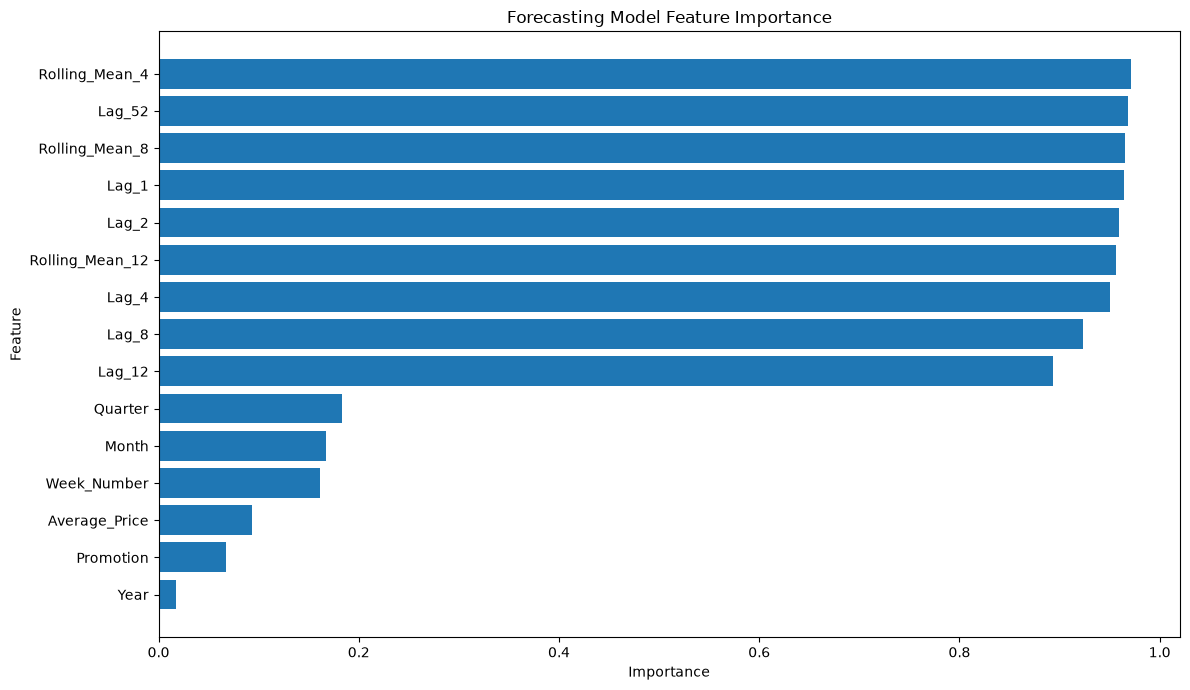

In [23]:
plt.figure(figsize=(12, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Forecasting Model Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
test_data.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/model_forecast_results.csv",
    index=False
)

feature_importance.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/model_feature_importance.csv",
    index=False
)

print("\nModel results saved successfully.")


Model results saved successfully.


In [30]:
# Stage 7 - Model Evaluation
# WAPE is the primary metric; MAE, RMSE, and forecast bias are supporting metrics.

import pandas as pd
import numpy as np

results_path = "D:/foresight-demand-inventory-intelligence/processed/model_forecast_results.csv"
df = pd.read_csv(results_path)

# Stage 6 saves these names. Rename them to the evaluation names used below.
column_mapping = {
    "Units_Sold": "Actual",
    "Model_Forecast": "Forecast",
}
df = df.rename(columns=column_mapping)

required_columns = ["Actual", "Forecast"]
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]
if missing_columns:
    raise KeyError(
        f"Missing evaluation columns: {missing_columns}. "
        f"Available columns: {df.columns.tolist()}"
    )

df = df.dropna(subset=required_columns).copy()
df["Error"] = df["Actual"] - df["Forecast"]
df["Absolute_Error"] = df["Error"].abs()

actual_total = df["Actual"].abs().sum()
if actual_total == 0:
    raise ValueError("Cannot calculate WAPE or bias because total actual demand is zero.")

mae = df["Absolute_Error"].mean()
rmse = np.sqrt((df["Error"] ** 2).mean())
wape = (df["Absolute_Error"].sum() / actual_total) * 100
bias = (df["Error"].sum() / actual_total) * 100

print("MODEL EVALUATION")
print("----------------")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"WAPE  : {wape:.2f}%")
print(f"Bias  : {bias:.2f}%")

evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "WAPE", "Bias"],
    "Value": [mae, rmse, wape, bias],
})

evaluation.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/model_evaluation_metrics.csv",
    index=False,
)

print("Evaluation results saved successfully.")

MODEL EVALUATION
----------------
MAE   : 13.48
RMSE  : 23.17
WAPE  : 16.85%
Bias  : -6.89%
Evaluation results saved successfully.


In [ ]:
# Stage 8: Risk Scoring

import pandas as pd

# 1. Load forecast data

forecast = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/processed/model_forecast_results.csv"
)

# Rename forecast column if needed
if "Model_Forecast" in forecast.columns:
    forecast = forecast.rename(columns={"Model_Forecast": "Forecast"})

# 2. Load ORIGINAL inventory data

inventory = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/Raw Datsets/inventory_snapshots.csv"
)

inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"],
    errors="coerce"
)
# 3. Get latest inventory snapshot for each SKU

latest_inventory = (
    inventory
    .sort_values("Snapshot_Date")
    .groupby("SKU")
    .tail(1)
)

latest_inventory = latest_inventory[
    [
        "SKU",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days"
    ]
].copy()

# 4. Convert inventory columns

latest_inventory["Current_Stock"] = pd.to_numeric(
    latest_inventory["Current_Stock"],
    errors="coerce"
)

latest_inventory["On_Order"] = pd.to_numeric(
    latest_inventory["On_Order"],
    errors="coerce"
)

latest_inventory["Lead_Time_Days"] = pd.to_numeric(
    latest_inventory["Lead_Time_Days"],
    errors="coerce"
)

# 5. Get latest forecast for each SKU

latest_forecast = (
    forecast[
        ["SKU", "Forecast"]
    ]
    .dropna(subset=["Forecast"])
    .groupby("SKU")
    .tail(1)
    .reset_index(drop=True)
)

latest_forecast["Forecast"] = pd.to_numeric(
    latest_forecast["Forecast"],
    errors="coerce"
)

# 6. Combine forecast + inventory

risk = latest_forecast.merge(
    latest_inventory,
    on="SKU",
    how="left"
)

# 7. Calculate lead-time demand

risk["Lead_Time_Demand"] = (
    risk["Forecast"]
    * risk["Lead_Time_Days"]
    / 7
)

# 8. Calculate available stock

risk["Available_Stock"] = (
    risk["Current_Stock"]
    + risk["On_Order"]
)
# 9. Stockout risk

risk["Stockout_Risk"] = (
    risk["Available_Stock"]
    < risk["Lead_Time_Demand"]
)

# 10. Overstock risk

risk["Overstock_Risk"] = (
    risk["Current_Stock"]
    > risk["Forecast"] * 4
)

# 11. Action

risk["Action"] = "MONITOR"

risk.loc[
    risk["Overstock_Risk"],
    "Action"
] = "OVERSTOCK"

# Stockout gets priority
risk.loc[
    risk["Stockout_Risk"],
    "Action"
] = "REORDER"

# 12. Check results

print("\nRisk Scoring Results:")
print(
    risk[
        [
            "SKU",
            "Forecast",
            "Current_Stock",
            "On_Order",
            "Lead_Time_Days",
            "Lead_Time_Demand",
            "Available_Stock",
            "Stockout_Risk",
            "Overstock_Risk",
            "Action"
        ]
    ].head(10)
)
# 13. Check risk counts

print("\nRisk Summary:")
print(
    risk["Action"].value_counts()
)

# 14. Check missing inventory values

print("\nMissing Inventory Values:")
print(
    risk[
        [
            "Current_Stock",
            "On_Order",
            "Lead_Time_Days"
        ]
    ].isna().sum()
)

# 15. Save risk results
risk.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/risk_scoring.csv",
    index=False
)

print("\nSaved: risk_scoring.csv")


Risk Scoring Results:
      SKU  Forecast  Current_Stock  On_Order  Lead_Time_Days  \
0  SKU001     86.00            771       147               4   
1  SKU002     53.00            526        29               3   
2  SKU003     32.00            349        12               3   
3  SKU004     33.75            259       254               6   
4  SKU005    101.75            471       291               6   
5  SKU006     40.50            359       485              13   
6  SKU007    152.25            207       460               8   
7  SKU008    103.50            325       155               3   
8  SKU009     76.25             75        89               7   
9  SKU010    109.50             83        70              13   

   Lead_Time_Demand  Available_Stock  Stockout_Risk  Overstock_Risk     Action  
0         49.142857              918          False            True  OVERSTOCK  
1         22.714286              555          False            True  OVERSTOCK  
2         13.714286          

In [2]:
# step 9: Decision table
import pandas as pd

# Load corrected risk scoring
risk = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/processed/risk_scoring.csv"
)

# Select decision-making columns
decision = risk[
    [
        "SKU",
        "Forecast",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Stockout_Risk",
        "Overstock_Risk",
        "Action"
    ]
].copy()

# Create priority
decision["Priority"] = "Normal"

decision.loc[
    decision["Overstock_Risk"] == True,
    "Priority"
] = "Medium"

decision.loc[
    decision["Stockout_Risk"] == True,
    "Priority"
] = "High"

# Sort by priority
priority_order = {
    "High": 1,
    "Medium": 2,
    "Normal": 3
}

decision = decision.sort_values(
    "Priority",
    key=lambda x: x.map(priority_order)
)

# Save decision table
decision.to_csv(
    "D:/foresight-demand-inventory-intelligence/processed/decision_table.csv",
    index=False
)

# Show results
print("Decision Table:")
print(decision.head(10))

print("\nPriority Summary:")
print(decision["Priority"].value_counts())

print("\nAction Summary:")
print(decision["Action"].value_counts())

print("\nSaved: decision_table.csv")

Decision Table:
       SKU  Forecast  Current_Stock  On_Order  Lead_Time_Days  Stockout_Risk  \
11  SKU012    160.75             47        60              12           True   
9   SKU010    109.50             83        70              13           True   
30  SKU031    107.25             93        40              13           True   
16  SKU017     95.00             95        26              12           True   
39  SKU040     93.25             67        29               9           True   
4   SKU005    101.75            471       291               6          False   
0   SKU001     86.00            771       147               4          False   
5   SKU006     40.50            359       485              13          False   
10  SKU011     20.00            753       269               3          False   
14  SKU015     25.25            187       245               9          False   

    Overstock_Risk     Action Priority  
11           False    REORDER     High  
9            False   

In [8]:
from pathlib import Path
import subprocess
import sys

# Run the dashboard as a Streamlit application, not as notebook st.* calls.
project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
app_path = project_dir / "app" / "streamlit_app.py"

if not app_path.exists():
    raise FileNotFoundError(f"Dashboard file not found: {app_path}")

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(app_path),
        "--server.port",
        "8501",
    ],
    cwd=project_dir,
)

print(f"Dashboard started with process ID {streamlit_process.pid}")
print("Open http://localhost:8501 in your browser.")

Dashboard started with process ID 8588
Open http://localhost:8501 in your browser.


In [9]:
# Stage 11: Rupee Impact Analysis

import pandas as pd

# Load corrected decision table
decision = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/processed/decision_table.csv"
)

# Make sure numeric columns are numeric
decision["Forecast"] = pd.to_numeric(
    decision["Forecast"], errors="coerce"
)

decision["Current_Stock"] = pd.to_numeric(
    decision["Current_Stock"], errors="coerce"
)

# Calculate inventory impact

# Estimated excess stock
decision["Excess_Stock"] = (
    decision["Current_Stock"] -
    decision["Forecast"] * 4
).clip(lower=0)

# Estimated stockout demand gap
decision["Stockout_Gap"] = (
    decision["Forecast"] -
    decision["Current_Stock"] -
    decision["On_Order"]
).clip(lower=0)

# Summary

reorder_count = (
    decision["Action"] == "REORDER"
).sum()

overstock_count = (
    decision["Action"] == "OVERSTOCK"
).sum()

monitor_count = (
    decision["Action"] == "MONITOR"
).sum()

print("Rupee Impact Analysis")
print("----------------------")

print("REORDER SKUs:", reorder_count)
print("OVERSTOCK SKUs:", overstock_count)
print("MONITOR SKUs:", monitor_count)

print("\nTotal estimated excess units:",
      decision["Excess_Stock"].sum())

print("Total estimated stockout gap:",
      decision["Stockout_Gap"].sum())

Rupee Impact Analysis
----------------------
REORDER SKUs: 5
OVERSTOCK SKUs: 21
MONITOR SKUs: 24

Total estimated excess units: 4909.0
Total estimated stockout gap: 53.75


In [11]:
# Stage 11: continue of Calculate Rupee Impact

import pandas as pd

# Load decision table.
decision = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/processed/decision_table.csv"
)

# Load SKU master and cost data.
sku_master = pd.read_csv(
    "D:/foresight-demand-inventory-intelligence/Raw Datsets/sku_master.csv"
)
sku_cost = sku_master[["SKU", "Cost_Price"]].copy()
sku_cost["Cost_Price"] = pd.to_numeric(
    sku_cost["Cost_Price"], errors="coerce"
)

# Convert decision values before calculating impact.
for column in ["Forecast", "Current_Stock", "On_Order"]:
    decision[column] = pd.to_numeric(decision[column], errors="coerce")

# Recreate temporary columns because they are not saved in decision_table.csv.
decision["Excess_Stock"] = (
    decision["Current_Stock"] - decision["Forecast"] * 4
).clip(lower=0)
decision["Stockout_Gap"] = (
    decision["Forecast"] - decision["Current_Stock"] - decision["On_Order"]
).clip(lower=0)

# Merge cost into the decision table.
decision = decision.merge(sku_cost, on="SKU", how="left")

# Calculate rupee impact.
decision["Excess_Inventory_Value"] = (
    decision["Excess_Stock"] * decision["Cost_Price"]
)
decision["Stockout_Exposure"] = (
    decision["Stockout_Gap"] * decision["Cost_Price"]
)

total_excess_value = decision["Excess_Inventory_Value"].sum()
total_stockout_exposure = decision["Stockout_Exposure"].sum()

print("Rupee Impact Analysis")
print("----------------------")
print(f"Excess Inventory Value: Rs {total_excess_value:,.2f}")
print(f"Stockout Exposure: Rs {total_stockout_exposure:,.2f}")
print(
    f"Total Potential Impact: Rs "
    f"{total_excess_value + total_stockout_exposure:,.2f}"
)

print("\nMissing Cost Prices:")
print(decision["Cost_Price"].isna().sum())

Rupee Impact Analysis
----------------------
Excess Inventory Value: Rs 15,093,567.07
Stockout Exposure: Rs 67,557.84
Total Potential Impact: Rs 15,161,124.91

Missing Cost Prices:
0


In [12]:
# Stage 12: Save Rupee Impact Analysis

report = decision[
    [
        "SKU",
        "Forecast",
        "Current_Stock",
        "On_Order",
        "Action",
        "Priority",
        "Cost_Price",
        "Excess_Stock",
        "Excess_Inventory_Value",
        "Stockout_Gap",
        "Stockout_Exposure"
    ]
].copy()

report.to_csv(
    "D:/foresight-demand-inventory-intelligence/reports/rupee_impact_analysis.csv",
    index=False
)

print("Saved:")
print("reports/rupee_impact_analysis.csv")

Saved:
reports/rupee_impact_analysis.csv
